## Factorization Machine

FM 二阶形式：
$$\hat{y}(x) = w_0 + \sum_{i=1}^n w_i x_i + \sum_{i=1}^n \sum_{j=i+1}^n \langle v_i, v_j \rangle x_i x_j$$

参数空间分析：
* $w_0$: 1 个参数。
* $w$: $n$ 个参数。
* $V \in \mathbb{R}^{n \times k}$: $n \times k$ 个参数。
* 总参数量：$1 + n + nk$。
* 复杂度降低：从 $O(n^2)$ 降低到了 $O(nk)$，由于 $k$ 通常很小（如 10~100），这使得模型在处理亿级特征时成为可能。

**泛化能力分析**：
即使 $(x_i, x_j)$ 在训练集中从未同时出现，我们依然可以计算 $\langle v_i, v_j \rangle$。因为 $v_i$ 是通过 $x_i$ 与其他特征（如 $x_k, x_l$）的交互学习到的，$v_j$ 同理。这种传递性使得 FM 具有强大的泛化能力。

* **计算复杂度的优化**：线性时间推导
    如果直接按照上述公式计算二阶项：
    $$\sum_{i=1}^n \sum_{j=i+1}^n \langle v_i, v_j \rangle x_i x_j$$
    时间复杂度仍然是 $O(kn^2)$，因为需要两层循环遍历所有特征对。FM 的精髓在于通过数学变换，将计算复杂度降低到 $O(kn)$。
    * 推导过程：
        考察二阶交互项（Interaction Term）：
        $$\text{Inter} = \sum_{i=1}^n \sum_{j=i+1}^n \langle v_i, v_j \rangle x_i x_j$$
        我们利用恒等式 $(a+b+c)^2 - (a^2+b^2+c^2) = 2(ab+bc+ac)$ 的推广形式：
        $$\sum_{i=1}^n \sum_{j=1}^n a_i a_j - \sum_{i=1}^n a_i^2 = 2 \sum_{i=1}^n \sum_{j=i+1}^n a_i a_j$$
        即：
        $$\sum_{i=1}^n \sum_{j=i+1}^n a_i a_j = \frac{1}{2} \left( (\sum_{i=1}^n a_i)^2 - \sum_{i=1}^n a_i^2 \right)$$
        将 $\langle v_i, v_j \rangle = \sum_{f=1}^k v_{if} v_{jf}$ 代入并交换求和顺序：
        $$
        \begin{aligned}
        \text{Inter} &= \sum_{i=1}^n \sum_{j=i+1}^n \left( \sum_{f=1}^k v_{if} v_{jf} \right) x_i x_j \\
        &= \sum_{f=1}^k \left( \sum_{i=1}^n \sum_{j=i+1}^n v_{if} x_i v_{jf} x_j \right)
        \end{aligned}
        $$
        应用上述平方和恒等式，括号内的部分可以重写为：
        $$\sum_{i=1}^n \sum_{j=i+1}^n (v_{if} x_i) (v_{jf} x_j) = \frac{1}{2} \left[ \left( \sum_{i=1}^n v_{if} x_i \right)^2 - \sum_{i=1}^n v_{if}^2 x_i^2 \right]$$
        得到最终公式：
        $$\hat{y}(x) = w_0 + \sum_{i=1}^n w_i x_i + \frac{1}{2} \sum_{f=1}^k \left[ \left( \sum_{i=1}^n v_{if} x_i \right)^2 - \sum_{i=1}^n v_{if}^2 x_i^2 \right]$$

        复杂度分析：
        * 内部求和 $\sum_{i=1}^n v_{if} x_i$ 的复杂度为 $O(n)$（实际上是 $O(\bar{n})$，$\bar{n}$ 为非零特征数）。
        * 外部求和 $\sum_{f=1}^k$ 的复杂度为 $k$。
        * 总复杂度：$O(k\bar{n})$。这是一个与特征非零个数成线性的复杂度，使得 FM 可以在线实时预测。




In [27]:
import torch
from torch import nn

class FactorizationMachine(nn.Module):
    def __init__(self, n, k=5):
        """
        params:
            - n: the dimension of feature vector w
            - k: the dimension of latent vector v
        """
        super().__init__()
        # 偏置项 w0 (scalar)
        self.w0 = nn.Parameter(torch.randn(size=[1]))
        # 一阶线性权重 w [n, 1]
        self.w = nn.Parameter(torch.randn(size=[n, 1]))
        # 二阶隐向量矩阵 V [n, k]
        # 初始化非常重要，通常使用 Xavier 或 Kaiming 初始化
        # self.V = nn.Parameter(torch.randn(size=[n, k])*0.01)    
        self.V = nn.Embedding(num_embeddings=n, embedding_dim=k)
        # 初始化（Embedding 默认初始化通常比较大，建议缩小）
        nn.init.normal_(self.V.weight, std=0.01)
   
    def forward(self, x):
        """
        params:
            - x: 输入特征矩阵 (Batch_size, n, 1)
        Returns:
            - y_hat: predictions (Batch_size, 1)
        """
        # Linear Term
        # Formula: y_linear = w_0 + w.T @ x
        # [1] + [1, n][Bacth_size, n, 1] -> [Batch, 1]
        y_linear = self.w0 + torch.matmul(x, self.w)
        
        # Interaction Term O(kn)
        # Formula: y_interaction = 0.5 * sum_f[sum_i(v_if * x_i)^2 - sum_i(v_fi^2 * x_i^2)]
        y_inter_1 = torch.pow(torch.matmul(x, self.V.weight),2)    # [batch_size, k]
        y_inter_2 = torch.matmul(torch.pow(x, 2), torch.pow(self.V.weight, 2))  # [batch_size, k]
        y_interaction = torch.sum((y_inter_1 - y_inter_2), dim=1, keepdim=True) # 保证维度为[batch, 1]
        
        y_hat = y_linear + y_interaction
        
        # 使用 Sigmoid 将输出映射到 (0, 1) 区间 (用于二分类)
        return y_hat

fm = FactorizationMachine(n=20, k=5)
fm.state_dict()

OrderedDict([('w0', tensor([0.7860])),
             ('w', tensor([[-0.4618],
                      [ 1.4200],
                      [ 0.8485],
                      [-0.0479],
                      [-0.6421],
                      [ 0.8266],
                      [-0.3646],
                      [ 0.0872],
                      [ 1.1225],
                      [ 0.0980],
                      [ 1.1226],
                      [ 1.2491],
                      [-1.2620],
                      [ 1.0861],
                      [-0.8786],
                      [ 2.5487],
                      [ 0.6594],
                      [ 0.6702],
                      [-0.1260],
                      [-0.6126]])),
             ('V.weight',
              tensor([[-7.8205e-06,  9.2348e-03, -1.1860e-02,  1.2986e-02,  8.9667e-03],
                      [-2.1818e-02,  6.1277e-04,  8.5261e-04,  6.8441e-03,  7.1139e-03],
                      [ 3.0481e-03,  5.1303e-03, -1.2514e-02, -8.3081e-03,  4.9816e-03],


In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np

X, y = make_classification(n_samples=10000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train_tensor = torch.from_numpy(X_train).type(torch.float)
X_test_tensor = torch.from_numpy(X_test).type(torch.float)
y_train_tensor = torch.from_numpy(y_train).type(torch.float)
y_test_tensor = torch.from_numpy(y_test).type(torch.float)

In [3]:
device = "cuda" if torch.cuda.is_available()\
            else 'mps' if torch.backends.mps.is_available()\
            else 'cpu'

device            

'mps'

In [4]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=32,
                              num_workers=0,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=32,
                             num_workers=0,
                             shuffle=False)

len(next(iter(train_dataloader))[0])

32

In [28]:
torch.manual_seed(42)

model = FactorizationMachine(n=20, k=5).to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model.parameters(),
                            lr=0.001)

In [29]:
NUM_EPOCH = 100
torch.manual_seed(42)

from tqdm.auto import tqdm

for epoch in tqdm(range(NUM_EPOCH)):
    ### Training
    model.train()
    train_loss = 0
    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)
        
        # Forward Pass
        y_pred = model(X)
        
        # Calculate loss
        loss = loss_fn(y_pred, y.unsqueeze(1))
        train_loss += loss.item()
        # optimizer zero_grad
        optimizer.zero_grad()
        
        # backward (BackPropogation)
        loss.backward()
        
        # optimizer step (gradient descent)
        optimizer.step()
    train_loss /= len(train_dataloader)
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Train Loss: {train_loss:.4f}")


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 1.7884
Epoch: 10 | Train Loss: 0.8497
Epoch: 20 | Train Loss: 0.5709
Epoch: 30 | Train Loss: 0.4548
Epoch: 40 | Train Loss: 0.3946
Epoch: 50 | Train Loss: 0.3579
Epoch: 60 | Train Loss: 0.3325
Epoch: 70 | Train Loss: 0.3132
Epoch: 80 | Train Loss: 0.2986
Epoch: 90 | Train Loss: 0.2883


0it [00:00, ?it/s]

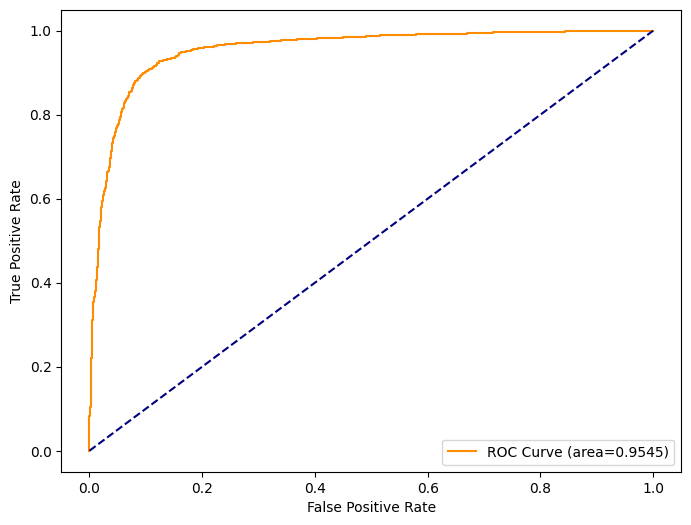

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

model.eval()
with torch.inference_mode():
    y_true = []
    test_prob = []
    for batch, (X, y) in tqdm(enumerate(test_dataloader)):
        X, y = X.to(device), y.to(device)
        # Forward pass
        test_pred_logits = model(X) # [Batch, 1]
        test_pred_prob = torch.sigmoid(test_pred_logits).to('cpu')
        # Calculate Loss
        # loss = loss_fn(y_pred, y)
        # 使用 extend 而不是 append 的核心原因是为了展平数据 (Flattening)
        # extend 会遍历 Batch 中的每一个元素，并逐个添加到列表中
        y_true.extend(y.cpu().numpy().flatten())  # 保证完全展平
        test_prob.extend(test_pred_prob.numpy().flatten())
            
fpr, tpr, _ = roc_curve(y_true, test_prob)
roc_auc = auc(fpr, tpr)
    
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f"ROC Curve (area={roc_auc:.4f})")
plt.plot([0,1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()